# Week 1 — First naive line simulation

## Goal

Build the smallest possible working model of local cross-correction.

The idea:

- some nuclei are corrected
- corrected nuclei produce signal
- signal spreads to nearby nuclei
- if enough signal accumulates locally, rescue may happen


## Why a 1D line?

A multinucleated muscle fibre is spatial. The easiest spatial abstraction is a line of nuclei.

That means:
- one list index = one nucleus
- `i - 1` is the left neighbour
- `i + 1` is the right neighbour

I chose this because it is easy to inspect and debug.

In [2]:
from __future__ import annotations

def run_naive_line(n_nodes=20, corrected_fraction=0.1, steps=50):
    signal = [0.0 for _ in range(n_nodes)]
    corrected = [False for _ in range(n_nodes)]
    n_corrected = max(1, round(n_nodes * corrected_fraction))
    for i in range(n_corrected):
        corrected[i] = True

    rescued = [False for _ in range(n_nodes)]

    for _ in range(steps):
        next_signal = signal[:]
        for i in range(n_nodes):
            left = signal[i - 1] if i > 0 else signal[i]
            right = signal[i + 1] if i < n_nodes - 1 else signal[i]
            production = 1.0 if corrected[i] else 0.0
            next_signal[i] = 0.6 * signal[i] + 0.2 * left + 0.2 * right + production * 0.05
            if next_signal[i] > 1.0:
                rescued[i] = True
        signal = next_signal

    return {"signal": signal, "rescued": rescued}

## Intuition behind the update rule

The line

`0.6 * current + 0.2 * left + 0.2 * right + production * 0.05`

means:

- keep some current signal
- mix in neighbour signal
- inject a little fresh signal at corrected nuclei

This is not yet derived from a diffusion equation. It is a first intuition-building rule.

In [3]:
result = run_naive_line()
result

{'signal': [1.3436930566081553,
  1.1795847200844682,
  0.8474455771172166,
  0.5899576351318263,
  0.3973455490965382,
  0.2585294741674259,
  0.16227177436088325,
  0.0981301214623738,
  0.057102835796737174,
  0.03193807116506482,
  0.017150657897655214,
  0.008833255004603944,
  0.004359056770270138,
  0.002059079240668064,
  0.0009301436545959172,
  0.00040145002733144925,
  0.0001654482472381683,
  6.524806682190392e-05,
  2.5254245201630978e-05,
  1.1591854927249441e-05],
 'rescued': [True,
  True,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False]}

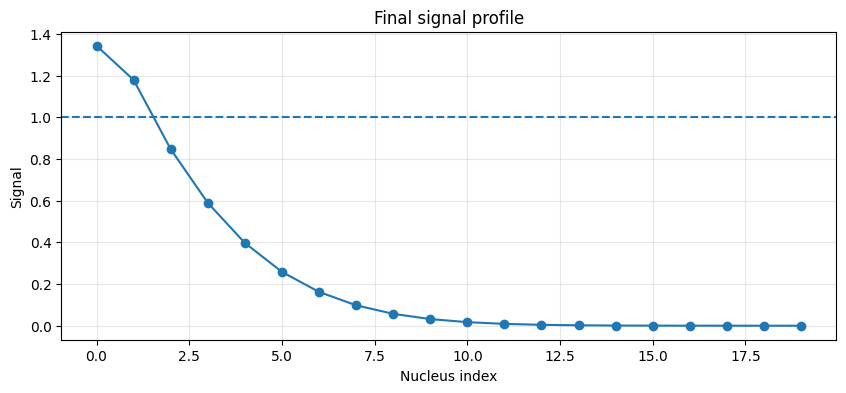

In [19]:
import matplotlib.pyplot as plt
import numpy as np

result = run_naive_line()

# final signal profile
x = list(range(len(result["signal"])))
plt.figure(figsize=(10, 4))
plt.plot(x, result["signal"], marker="o")
plt.axhline(1.0, linestyle="--")
plt.xlabel("Nucleus index")
plt.ylabel("Signal")
plt.title("Final signal profile")
plt.grid(True, alpha=0.3)
plt.show()

### Visualisation 1 — Final signal profile

#### Key insights

- The final signal decreases smoothly as nucleus index increases, showing that signal spreads outward from the corrected source region but weakens with distance.
- Only the first two nuclei lie above the rescue threshold of `1.0`, so local transport occurs, but functional rescue remains spatially limited.
- The monotonic decay pattern suggests that the update rule behaves like a discrete diffusion-style process rather than producing unstable or oscillatory behaviour.
- Because corrected nuclei are placed at the start of the line, the plot represents propagation from a clustered boundary source rather than a distributed correction pattern.
- This result suggests that under the current assumptions, local signal spread alone is not strong enough to rescue distant nuclei.

In [ ]:
def plot_rescue_map(result):
    rescued = result["rescued"]
    x = list(range(len(rescued)))
    y = [1 if r else 0 for r in rescued]

    plt.figure(figsize=(10, 2.5))
    plt.scatter(x, y, s=100)
    plt.yticks([0, 1], ["Not rescued", "Rescued"])
    plt.xlabel("Nucleus index")
    plt.title("Week 1 rescue pattern")
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()

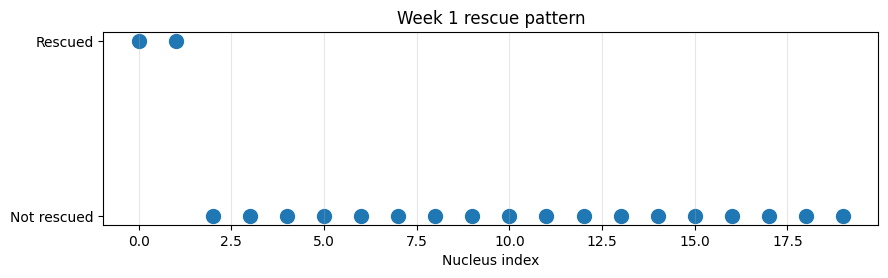

In [9]:
plot_rescue_map(result)

### Visualisation 2 — Rescue pattern

#### Key insights

- Only nuclei `0` and `1` are rescued, which matches the final signal plot where only these nodes exceed the threshold.
- The rescue outcome shows that signal presence and rescue are not the same thing, since many nuclei receive nonzero signal but still remain below the rescue threshold.
- The binary threshold rule creates a sharp boundary between corrected and uncorrected regions, even though the signal itself changes smoothly.
- This highlights that the main limitation in the current model is not whether signal spreads, but whether enough signal accumulates to trigger rescue.
- The result motivates exploring more biologically realistic rescue rules later, such as cumulative exposure instead of instantaneous threshold crossing.


In [10]:
def run_naive_line_with_history(n_nodes=20, corrected_fraction=0.1, steps=50):
    signal = [0.0 for _ in range(n_nodes)]
    corrected = [False for _ in range(n_nodes)]
    n_corrected = max(1, round(n_nodes * corrected_fraction))
    for i in range(n_corrected):
        corrected[i] = True

    rescued = [False for _ in range(n_nodes)]
    history = [signal[:]]

    for _ in range(steps):
        next_signal = signal[:]
        for i in range(n_nodes):
            left = signal[i - 1] if i > 0 else signal[i]
            right = signal[i + 1] if i < n_nodes - 1 else signal[i]
            production = 1.0 if corrected[i] else 0.0
            next_signal[i] = 0.6 * signal[i] + 0.2 * left + 0.2 * right + production * 0.05
            if next_signal[i] > 1.0:
                rescued[i] = True
        signal = next_signal
        history.append(signal[:])

    return {"signal": signal, "rescued": rescued, "history": history}

In [15]:
import numpy as np

def plot_signal_heatmap(result):
    history = np.array(result["history"])

    plt.figure(figsize=(10, 6))
    plt.imshow(history, aspect="auto", origin="lower")
    plt.colorbar(label="Signal")
    plt.xlabel("Nucleus index")
    plt.ylabel("Time step")
    plt.title("Signal propagation over time")
    plt.show()

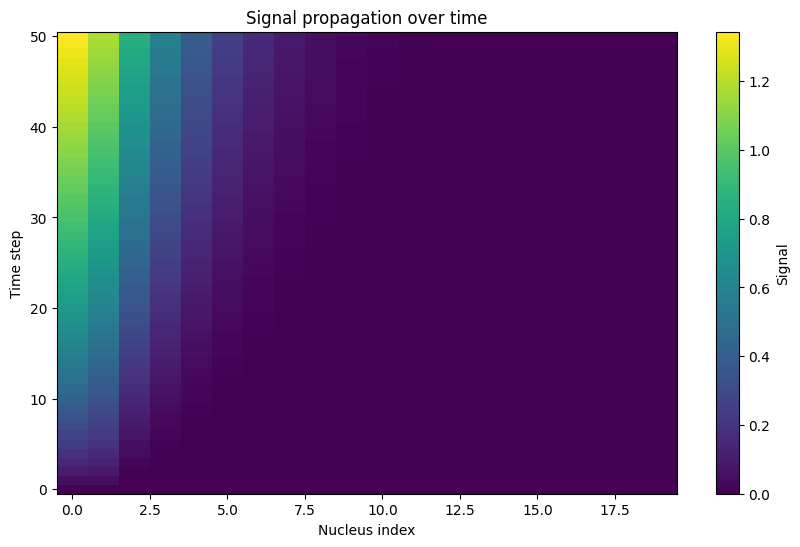

In [17]:
result_hist = run_naive_line_with_history()
plot_signal_heatmap(result_hist)

### Visualisation 3 — Signal propagation heatmap

#### Key insights

- Signal first appears at the corrected nuclei and then spreads gradually to neighbouring nuclei over time, confirming that propagation is local and iterative.
- The heatmap shows a clear left-to-right expansion of influence before the system settles into a stable spatial gradient.
- Signal intensity becomes weaker both with increasing distance from the source and after the system approaches equilibrium.
- The emergence of a steady-state profile suggests that the update rule is stable and approximates a diffusion-like transport process with continuous source input.
- This visualisation shows that transport is a time-dependent process, which supports the idea that rescue may be better modelled using accumulated exposure in later versions.


### Overall conclusion

- The Week 1 model successfully demonstrates spatial signal propagation from corrected nuclei.
- Signal spreads beyond the source region, but rescue remains confined to nuclei near the source because the threshold is only crossed locally.
- The update rule appears stable and already captures the qualitative behaviour of diffusion-like transport.
- The main modelling limitation is that rescue is based on instantaneous signal rather than cumulative exposure.
- These results justify the next modelling step: replacing heuristic neighbour averaging with a more formal graph-based diffusion operator.